# Load data

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import Counter


In [ ]:
!pip install -q datasets pandas pyarrow huggingface_hub

In [50]:
from huggingface_hub import hf_hub_download
from datasets import load_dataset

repo_id = "uitnlp/vietnamese_students_feedback"

train_file = hf_hub_download(
    repo_id=repo_id,
    repo_type="dataset",
    revision="refs/convert/parquet",
    filename="default/train/0000.parquet"
)

val_file = hf_hub_download(
    repo_id=repo_id,
    repo_type="dataset",
    revision="refs/convert/parquet",
    filename="default/validation/0000.parquet"
)

test_file = hf_hub_download(
    repo_id=repo_id,
    repo_type="dataset",
    revision="refs/convert/parquet",
    filename="default/test/0000.parquet"
)

ds = load_dataset(
    "parquet",
    data_files={
        "train": train_file,
        "validation": val_file,
        "test": test_file
    }
)

print(ds)
print(ds["train"][0])

DatasetDict({
    train: Dataset({
        features: ['sentence', 'sentiment', 'topic'],
        num_rows: 11426
    })
    validation: Dataset({
        features: ['sentence', 'sentiment', 'topic'],
        num_rows: 1583
    })
    test: Dataset({
        features: ['sentence', 'sentiment', 'topic'],
        num_rows: 3166
    })
})
{'sentence': 'slide giáo trình đầy đủ .', 'sentiment': 2, 'topic': 1}


In [51]:
import pandas as pd

train_df = ds["train"].to_pandas()
val_df = ds["validation"].to_pandas()
test_df = ds["test"].to_pandas()

train_df.to_csv("/content/drive/MyDrive/CCNLTHD/data/uit_vsfc_train.csv", index=False, encoding="utf-8-sig")
val_df.to_csv("/content/drive/MyDrive/CCNLTHD/data/uit_vsfc_validation.csv", index=False, encoding="utf-8-sig")
test_df.to_csv("/content/drive/MyDrive/CCNLTHD/data/uit_vsfc_test.csv", index=False, encoding="utf-8-sig")

# Thống kê mô tả

In [52]:
#train_df.columns.to_list()
#val_df.columns.to_list()
test_df.columns.to_list()

['sentence', 'sentiment', 'topic']

In [53]:
train_df.describe()

,sentiment,topic
count,11426.000000,11426.000000
mean,1.027831,0.427184
std,0.979401,0.791747
min,0.000000,0.000000
25%,0.000000,0.000000
50%,1.000000,0.000000
75%,2.000000,1.000000
max,2.000000,3.000000


In [54]:
val_df.describe()

,sentiment,topic
count,1583.000000,1583.000000
mean,1.063171,0.437145
std,0.974933,0.833669
min,0.000000,0.000000
25%,0.000000,0.000000
50%,2.000000,0.000000
75%,2.000000,1.000000
max,2.000000,3.000000


In [55]:
test_df.describe()

,sentiment,topic
count,3166.000000,3166.000000
mean,1.057170,0.422931
std,0.971742,0.798240
min,0.000000,0.000000
25%,0.000000,0.000000
50%,2.000000,0.000000
75%,2.000000,1.000000
max,2.000000,3.000000


In [56]:
#train_df.isnull().sum()
train_df['sentence'].duplicated().sum()

np.int64(1)

In [57]:
#val_df.isnull().sum()
val_df['sentence'].duplicated().sum()

np.int64(0)

In [58]:
#test_df.isnull().sum()
test_df['sentence'].duplicated().sum()

np.int64(0)

In [59]:
print("so dong tap train", train_df.shape)
print("so dong tap val",val_df.shape)
print("so dong tap test",test_df.shape)


so dong tap train (11426, 3)
so dong tap val (1583, 3)
so dong tap test (3166, 3)


In [60]:
duplicate_sentences = train_df[train_df["sentence"].duplicated(keep=False)].sort_values("sentence")
duplicate_sentences

,sentence,sentiment,topic
11293,"thầy dạy hay , tuy nhiên còn nhiều chỗ chưa th...",2,0
11417,"thầy dạy hay , tuy nhiên còn nhiều chỗ chưa th...",0,0


Xử lý câu trùng lặp

In [61]:
train_df.drop(index=11293, inplace=True)

In [62]:
11293 in train_df.index

False

In [63]:
train_df['sentence'].duplicated().sum()

np.int64(0)

In [64]:
#Kiểm tra sentence rỗng

print("Train empty sentence:", (train_df["sentence"].astype(str).str.strip() == "").sum())
print("Validation empty sentence:", (val_df["sentence"].astype(str).str.strip() == "").sum())
print("Test empty sentence:", (test_df["sentence"].astype(str).str.strip() == "").sum())

Train empty sentence: 0
Validation empty sentence: 0
Test empty sentence: 0


In [65]:
#Kiểm tra sentence trùng giữa các tập

train_sentences = set(train_df["sentence"].astype(str).str.strip())
val_sentences = set(val_df["sentence"].astype(str).str.strip())
test_sentences = set(test_df["sentence"].astype(str).str.strip())

print("Train ∩ Validation:", len(train_sentences & val_sentences))
print("Train ∩ Test:", len(train_sentences & test_sentences))
print("Validation ∩ Test:", len(val_sentences & test_sentences))

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


Gộp thành 1 file

In [69]:
train_df["split"] = "train"
val_df["split"] = "validation"
test_df["split"] = "test"

all_df = pd.concat([train_df, val_df, test_df], ignore_index=True)


print("Tổng số dòng theo split:")
print(all_df["split"].value_counts())

all_df.head()

Tổng số dòng theo split:
split
train         11425
test           3166
validation     1583
Name: count, dtype: int64


,sentence,sentiment,topic,split,sentiment_labels,topic_labels
0,slide giáo trình đầy đủ .,2,1,train,positive,training_program
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",2,0,train,positive,lecturer
2,đi học đầy đủ full điểm chuyên cần .,0,1,train,negative,training_program
3,chưa áp dụng công nghệ thông tin và các thiết ...,0,0,train,negative,lecturer
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",2,0,train,positive,lecturer


In [67]:
print("Các giá trị của sentiment:", sorted(train_df["sentiment"].unique()))
print("Các giá trị của topic:", sorted(train_df["topic"].unique()))

Các giá trị của sentiment: [np.int64(0), np.int64(1), np.int64(2)]
Các giá trị của topic: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


In [70]:
sentiment_map = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

topic_map = {
    0: "lecturer",
    1: "training_program",
    2: "facility",
    3: "others"
}

train_df["sentiment_labels"] = train_df["sentiment"].map(sentiment_map)
train_df["topic_labels"] = train_df["topic"].map(topic_map)

val_df["sentiment_labels"] = val_df["sentiment"].map(sentiment_map)
val_df["topic_labels"] = val_df["topic"].map(topic_map)

test_df["sentiment_labels"] = test_df["sentiment"].map(sentiment_map)
test_df["topic_labels"] = test_df["topic"].map(topic_map)

all_df["sentiment_labels"] = all_df["sentiment"].map(sentiment_map)
all_df["topic_labels"] = all_df["topic"].map(topic_map)



In [71]:
all_df.head()

,sentence,sentiment,topic,split,sentiment_labels,topic_labels
0,slide giáo trình đầy đủ .,2,1,train,positive,training_program
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",2,0,train,positive,lecturer
2,đi học đầy đủ full điểm chuyên cần .,0,1,train,negative,training_program
3,chưa áp dụng công nghệ thông tin và các thiết ...,0,0,train,negative,lecturer
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",2,0,train,positive,lecturer


In [72]:
#Tỷ lệ nhãn theo phần trăm
print("Sentiment train (%):")
print((train_df["sentiment"].value_counts(normalize=True).sort_index() * 100).round(2))

print("\nTopic train (%):")
print((train_df["topic"].value_counts(normalize=True).sort_index() * 100).round(2))

Sentiment train (%):
sentiment
0    46.61
1     4.01
2    49.38
Name: proportion, dtype: float64

Topic train (%):
topic
0    71.47
1    19.26
2     4.35
3     4.92
Name: proportion, dtype: float64


In [73]:
#Kiểm tra câu quá ngắn hoặc quá dài

all_df["char_length"] = all_df["sentence"].astype(str).apply(len)
all_df["word_count"] = all_df["sentence"].astype(str).apply(lambda x: len(x.split()))

print(all_df[["sentence", "word_count"]].sort_values("word_count").head(10))
print(all_df[["sentence", "word_count"]].sort_values("word_count", ascending=False).head(10))

          sentence  word_count
7123        thân !           2
15891     thanks !           2
3988        hiền .           2
4064        xinh .           2
11721       good .           2
7818         hay .           2
11903        tốt .           2
756         nope .           2
4117   listening .           2
823         thân .           2
                                                sentence  word_count
12491  giảng viên rất nhiệt tình thậm chí dạy lố giờ ...         161
3754   thầy cho nghỉ quá nhiểu mà không sắp xếp giáo ...         159
8670   thầy nên hướng dẫn cụ thể về vấn đề đồ án , bọ...         123
7057   nội dung học chất lượng nhưng khá đơn giản , t...         110
6657   môn học là kiểm chứng phần mềm , nhưng tất cả ...         106
3057   sinh viên rất khó nắm bắt những gì giảng viên ...          98
13250  thực hành hình thức 2 tỏ ra kém hiệu quả , chủ...          98
15511  cơ sở vật chất cần tăng cường hơn , vệ sinh ph...          97
3408   đặc biệt cần thông tin cụ thể v

In [74]:
#Độ dài câu theo từng nhãn

print(all_df.groupby("sentiment_labels")["word_count"].mean().round(2))
print(all_df.groupby("topic_labels")["word_count"].mean().round(2))

sentiment_labels
negative    16.89
neutral      9.82
positive    12.15
Name: word_count, dtype: float64
topic_labels
facility            16.97
lecturer            13.70
others               9.95
training_program    16.76
Name: word_count, dtype: float64


In [78]:
#Tiền xử lý văn bản chuyên sâu

!pip install underthesea -q
from underthesea import word_tokenize

def preprocess_text(text):
    # Chuyển về chữ thường
    text = text.lower()
    # Xóa ký tự đặc biệt và số
    text = re.sub(r'[^\w\s]', '', text)
    # Tách từ tiếng Việt (Tokenization)
    text = word_tokenize(text, format="text")
    # Xóa khoảng trắng thừa
    text = " ".join(text.split())
    return text

# Áp dụng cho tập train
train_df['clean_sentence'] = train_df['sentence'].apply(preprocess_text)
print(train_df[['sentence', 'clean_sentence']].head())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 49.6 MB/s eta 0:00:00
                                            sentence  \
0                          slide giáo trình đầy đủ .   
1     nhiệt tình giảng dạy , gần gũi với sinh viên .   
2               đi học đầy đủ full điểm chuyên cần .   
3  chưa áp dụng công nghệ thông tin và các thiết ...   
4  thầy giảng bài hay , có nhiều bài tập ví dụ ng...   

                                      clean_sentence  
0                            slide giáo_trình đầy_đủ  
1         nhiệt_tình giảng_dạy gần_gũi với sinh_viên  
2                 đi học đầy_đủ full_điểm chuyên cần  
3  chưa áp_dụng công_nghệ_thông_tin và các thiết_...  
4  thầy giảng bài hay có nhiều bài_tập ví_dụ ngay...  


# Trực quan hóa dữ liệu

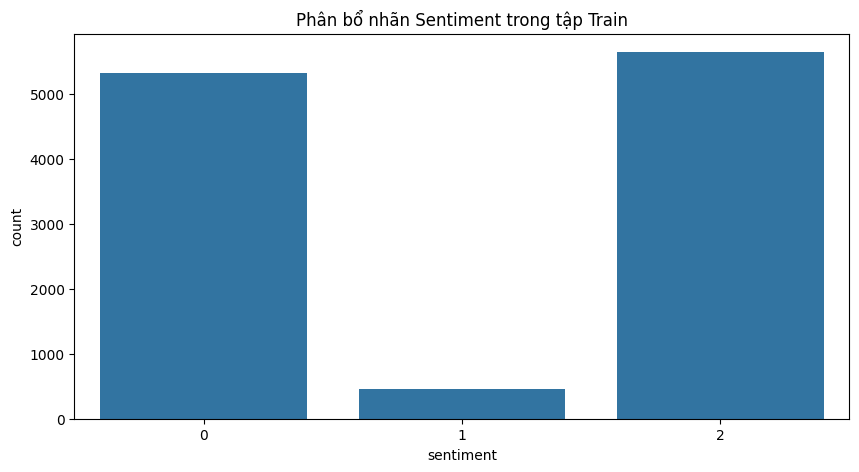

Tỷ lệ các nhãn sentiment:
sentiment
2    49.382932
0    46.608315
1     4.008753
Name: proportion, dtype: float64


In [76]:
import seaborn as sns

# Vẽ biểu đồ phân bổ nhãn sentiment
plt.figure(figsize=(10, 5))
sns.countplot(x='sentiment', data=train_df)
plt.title('Phân bổ nhãn Sentiment trong tập Train')
plt.show()

# Tính tỷ lệ phần trăm
print("Tỷ lệ các nhãn sentiment:")
print(train_df['sentiment'].value_counts(normalize=True) * 100)

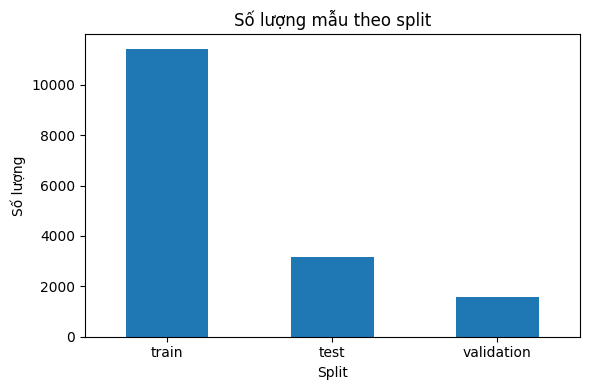

In [ ]:
plt.figure(figsize=(6, 4))
all_df["split"].value_counts().plot(kind="bar")
plt.title("Số lượng mẫu theo split")
plt.xlabel("Split")
plt.ylabel("Số lượng")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Bảng phân bố sentiment theo split:
sentiment_labels  negative  neutral  positive
split                                        
test                  1409      167      1590
train                 5325      458      5643
validation             705       73       805


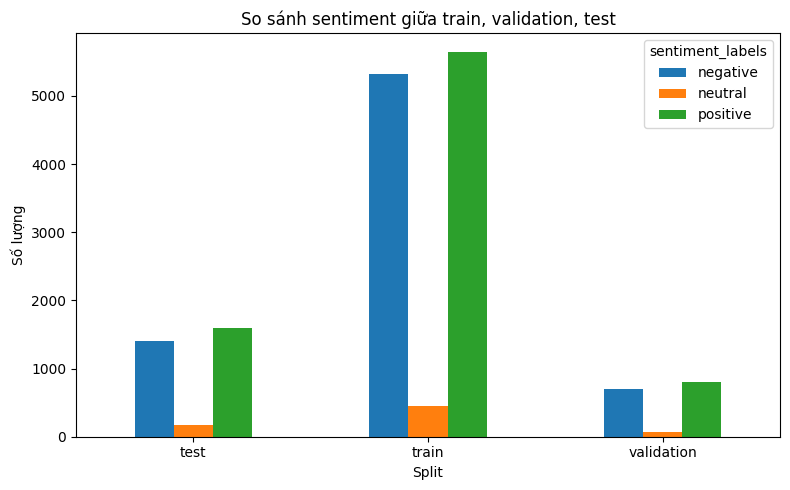

In [ ]:
if "sentiment" in all_df.columns:
    print("Bảng phân bố sentiment theo split:")
    sentiment_compare = pd.crosstab(all_df["split"], all_df["sentiment_labels"])
    print(sentiment_compare)

    sentiment_compare.plot(kind="bar", figsize=(8, 5))
    plt.title("So sánh sentiment giữa train, validation, test")
    plt.xlabel("Split")
    plt.ylabel("Số lượng")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

Bảng phân bố topic theo split:
topic_labels  facility  lecturer  others  training_program
split                                                     
test               145      2290     159               572
train              497      8166     562              2201
validation          70      1151      95               267


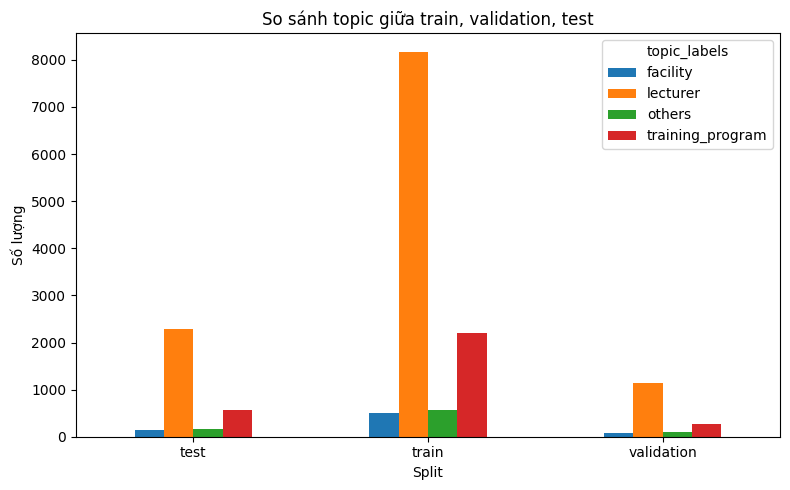

In [ ]:
if "topic" in all_df.columns:
    print("Bảng phân bố topic theo split:")
    topic_compare = pd.crosstab(all_df["split"], all_df["topic_labels"])
    print(topic_compare)

    topic_compare.plot(kind="bar", figsize=(8, 5))
    plt.title("So sánh topic giữa train, validation, test")
    plt.xlabel("Split")
    plt.ylabel("Số lượng")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


4. Độ dài câu trung bình theo split:
            char_length  word_count
split                              
test              58.84       14.22
train             59.08       14.31
validation        56.36       13.67


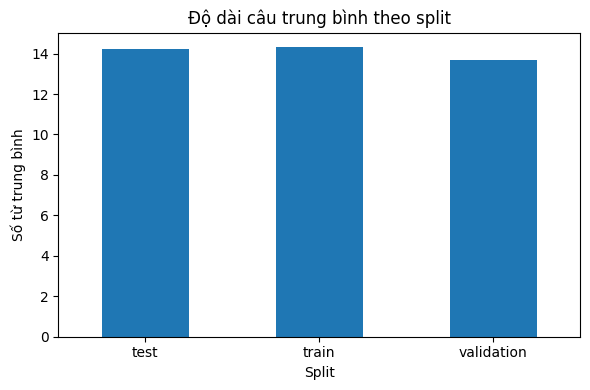

In [ ]:

if "sentence" in all_df.columns:
    all_df["char_length"] = all_df["sentence"].astype(str).apply(len)
    all_df["word_count"] = all_df["sentence"].astype(str).apply(lambda x: len(x.split()))

    print("Độ dài câu trung bình theo split:")
    print(all_df.groupby("split")[["char_length", "word_count"]].mean().round(2))

    avg_len = all_df.groupby("split")["word_count"].mean()

    plt.figure(figsize=(6, 4))
    avg_len.plot(kind="bar")
    plt.title("Độ dài câu trung bình theo split")
    plt.xlabel("Split")
    plt.ylabel("Số từ trung bình")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

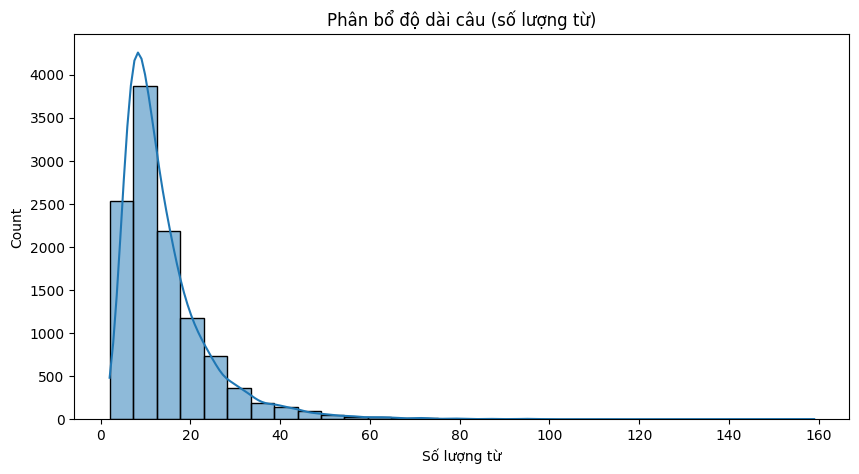

Độ dài trung bình: 14.31
Độ dài lớn nhất: 159


In [77]:
# Tính số lượng từ trong mỗi câu
train_df['word_count'] = train_df['sentence'].str.split().str.len()

plt.figure(figsize=(10, 5))
sns.histplot(train_df['word_count'], bins=30, kde=True)
plt.title('Phân bổ độ dài câu (số lượng từ)')
plt.xlabel('Số lượng từ')
plt.show()

print(f"Độ dài trung bình: {train_df['word_count'].mean():.2f}")
print(f"Độ dài lớn nhất: {train_df['word_count'].max()}")